In [1]:
!git clone https://github.com/naatlabia-lang/spine-curve-geometric-representation.git

Cloning into 'spine-curve-geometric-representation'...
remote: Enumerating objects: 2053, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2053 (delta 5), reused 1 (delta 0), pack-reused 2035 (from 1)
Receiving objects: 100% (2053/2053), 413.17 MiB | 31.03 MiB/s, done.
Resolving deltas: 100% (204/204), done.
Updating files: 100% (2019/2019), done.


In [3]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

INDEX_CSV = "/content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/dataset_index.csv"
DATASET_ROOT = Path("/content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset")

df = pd.read_csv(INDEX_CSV)

print("Shape:", df.shape)
print("Columnas:")
print(df.columns.tolist())

display(df.head())

Shape: (250, 9)
Columnas:
['split', 'image', 'patient_id', 'radiograph_path', 'label_binary_path', 'multiclass_id_png', 'multiclass_gray_jpg', 'multiclass_color_jpg', 'metrics_json']


,split,image,patient_id,radiograph_path,label_binary_path,multiclass_id_png,multiclass_gray_jpg,multiclass_color_jpg,metrics_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN


In [4]:
def resolve_path(root, rel_path):
    if pd.isna(rel_path):
        return None
    p = Path(str(rel_path))
    if p.is_absolute():
        return p
    return root / p

# Ajusta estos nombres si tu CSV usa otros
RX_COL = "rx_path" if "rx_path" in df.columns else "radiograph_path"
BIN_COL = "label_binary_path" if "label_binary_path" in df.columns else None

df["rx_abs_path"] = df[RX_COL].apply(lambda x: resolve_path(DATASET_ROOT, x))

if BIN_COL:
    df["binary_abs_path"] = df[BIN_COL].apply(lambda x: resolve_path(DATASET_ROOT, x))

df["rx_exists"] = df["rx_abs_path"].apply(lambda p: p.exists() if p else False)

print("Imágenes encontradas:", df["rx_exists"].sum(), "/", len(df))

display(df[["patient_id", RX_COL, "rx_abs_path", "rx_exists"]].head())

Imágenes encontradas: 250 / 250


,patient_id,radiograph_path,rx_abs_path,rx_exists
0,1,Normal/N_1.jpg,/content/spine-curve-geometric-representation/...,True
1,2,Normal/N_2.jpg,/content/spine-curve-geometric-representation/...,True
2,3,Normal/N_3.jpg,/content/spine-curve-geometric-representation/...,True
3,4,Normal/N_4.jpg,/content/spine-curve-geometric-representation/...,True
4,5,Normal/N_5.jpg,/content/spine-curve-geometric-representation/...,True


In [5]:
def inspect_image(path):
    path = str(path)
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        return {
            "exists": False,
            "height": None,
            "width": None,
            "channels": None,
            "dtype": None,
            "min": None,
            "max": None,
            "mean": None,
            "std": None,
            "p1": None,
            "p50": None,
            "p99": None,
        }

    if img.ndim == 2:
        gray = img
        channels = 1
    else:
        channels = img.shape[2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return {
        "exists": True,
        "height": img.shape[0],
        "width": img.shape[1],
        "channels": channels,
        "dtype": str(img.dtype),
        "min": float(np.min(gray)),
        "max": float(np.max(gray)),
        "mean": float(np.mean(gray)),
        "std": float(np.std(gray)),
        "p1": float(np.percentile(gray, 1)),
        "p50": float(np.percentile(gray, 50)),
        "p99": float(np.percentile(gray, 99)),
    }

records = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    info = inspect_image(row["rx_abs_path"])
    info["patient_id"] = row.get("patient_id", None)
    info["rx_path"] = str(row["rx_abs_path"])
    records.append(info)

audit_df = pd.DataFrame(records)

display(audit_df.head())
print(audit_df.describe(include="all"))

100%|██████████| 250/250 [00:11<00:00, 22.36it/s]


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
0,True,971,259,3,uint8,0.0,255.0,102.811837,45.020259,9.0,111.0,182.0,1,/content/spine-curve-geometric-representation/...
1,True,828,218,3,uint8,0.0,255.0,107.687680,59.316895,18.0,101.0,245.0,2,/content/spine-curve-geometric-representation/...
2,True,939,206,3,uint8,0.0,255.0,94.283735,34.371625,27.0,99.0,156.0,3,/content/spine-curve-geometric-representation/...
3,True,878,204,3,uint8,0.0,255.0,98.324875,45.059816,19.0,99.0,212.0,4,/content/spine-curve-geometric-representation/...
4,True,666,172,3,uint8,0.0,221.0,99.736609,49.714559,0.0,106.0,189.0,5,/content/spine-curve-geometric-representation/...


       exists       height        width  channels  dtype         min  \
count     250   250.000000   250.000000     250.0    250  250.000000   
unique      1          NaN          NaN       NaN      1         NaN   
top      True          NaN          NaN       NaN  uint8         NaN   
freq      250          NaN          NaN       NaN    250         NaN   
mean      NaN  1309.616000   519.580000       3.0    NaN    2.424000   
std       NaN   919.388764   487.434011       0.0    NaN    5.020862   
min       NaN   595.000000   123.000000       3.0    NaN    0.000000   
25%       NaN   782.750000   212.250000       3.0    NaN    0.000000   
50%       NaN   919.500000   318.000000       3.0    NaN    0.000000   
75%       NaN  1020.750000   551.750000       3.0    NaN    2.750000   
max       NaN  4999.000000  2972.000000       3.0    NaN   28.000000   

               max        mean         std          p1         p50  \
count   250.000000  250.000000  250.000000  250.000000  250.00000

,height,width,count
0,595,150,1
1,606,164,1
2,608,168,1
3,625,272,1
4,627,344,1
...,...,...,...
245,3962,1855,1
246,4156,2547,1
247,4286,1973,1
248,4773,1256,1


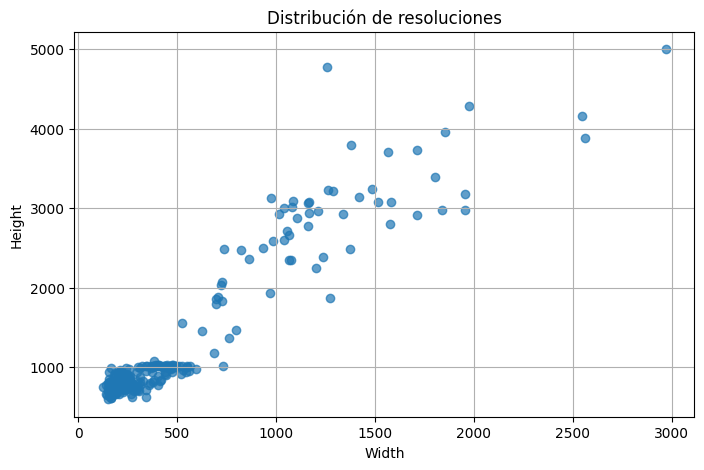

In [6]:
resolution_summary = (
    audit_df
    .groupby(["height", "width"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(resolution_summary)

plt.figure(figsize=(8, 5))
plt.scatter(audit_df["width"], audit_df["height"], alpha=0.7)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribución de resoluciones")
plt.grid(True)
plt.show()

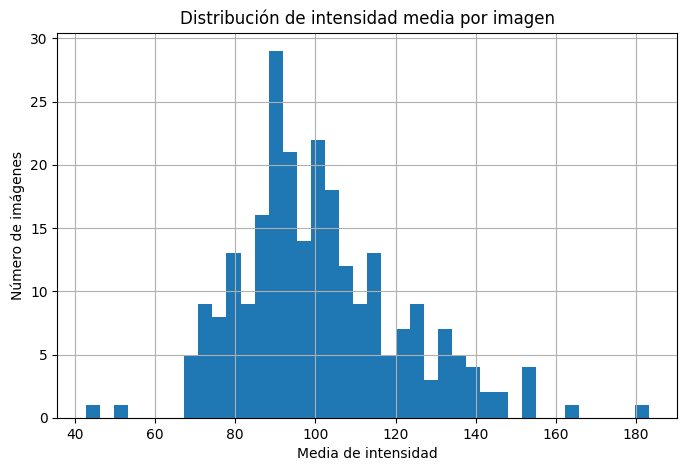

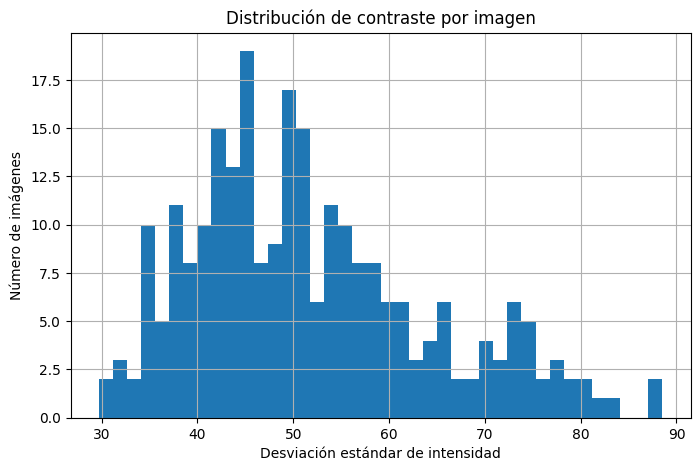

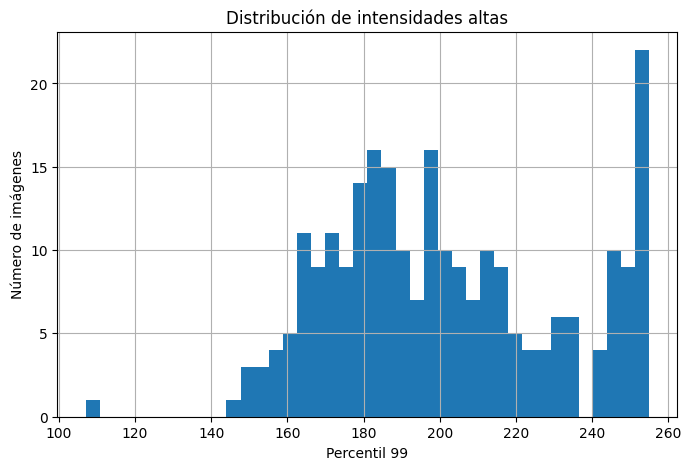

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(audit_df["mean"].dropna(), bins=40)
plt.xlabel("Media de intensidad")
plt.ylabel("Número de imágenes")
plt.title("Distribución de intensidad media por imagen")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(audit_df["std"].dropna(), bins=40)
plt.xlabel("Desviación estándar de intensidad")
plt.ylabel("Número de imágenes")
plt.title("Distribución de contraste por imagen")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(audit_df["p99"].dropna(), bins=40)
plt.xlabel("Percentil 99")
plt.ylabel("Número de imágenes")
plt.title("Distribución de intensidades altas")
plt.grid(True)
plt.show()

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_93.jpg
Shape: (1181, 684, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 137.66767062307193 Std: 48.58841222270906
P1: 21.0 P50: 144.0 P99: 219.0


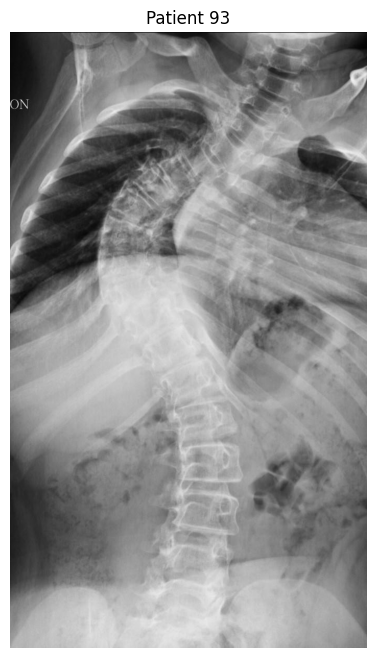

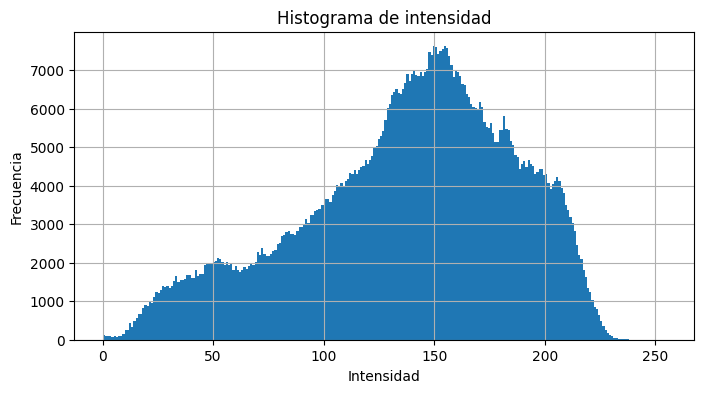

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Normal/N_7.jpg
Shape: (937, 220, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 92.64493062966916 Std: 35.037818280674166
P1: 27.0 P50: 98.0 P99: 156.0


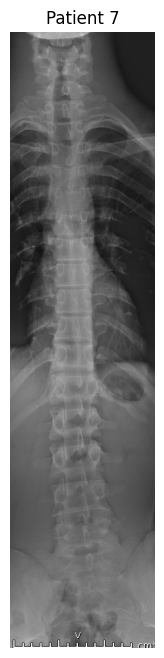

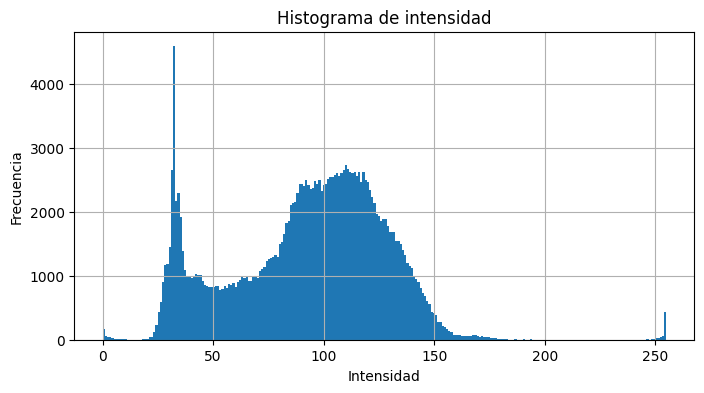

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_47.jpg
Shape: (1008, 432, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 79.71700011022928 Std: 55.41306070088735
P1: 7.0 P50: 80.0 P99: 198.0


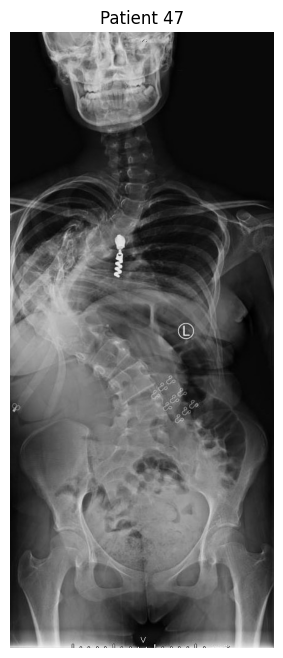

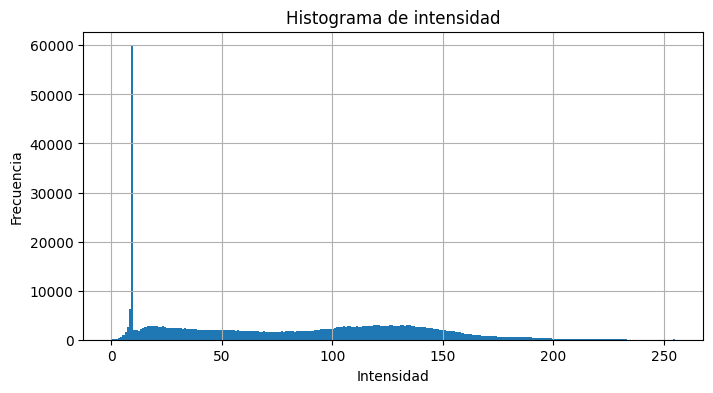

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Normal/N_61.jpg
Shape: (717, 291, 3)
Dtype: uint8
Min: 0 Max: 226
Mean: 71.1384251870384 Std: 40.1410660114822
P1: 11.0 P50: 64.0 P99: 177.0


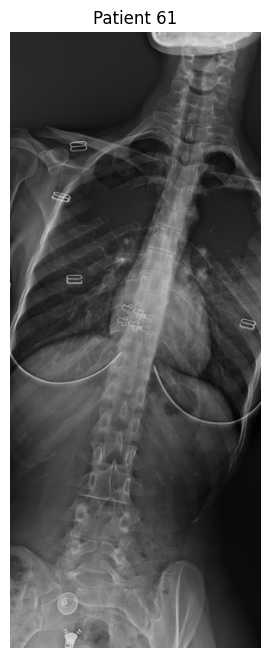

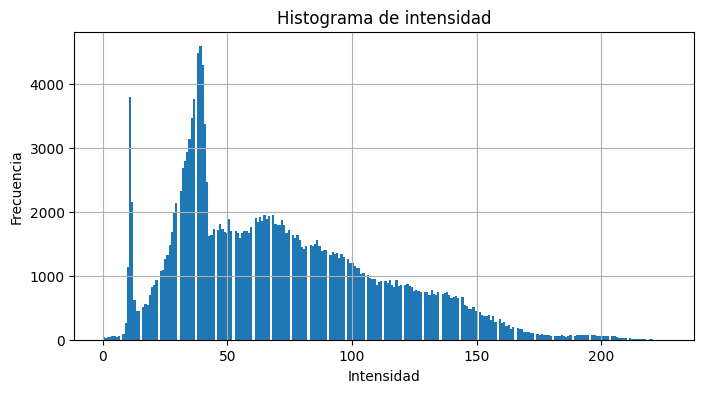

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_62.jpg
Shape: (1005, 441, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 88.92019043106463 Std: 61.24279091846398
P1: 7.0 P50: 80.0 P99: 251.0


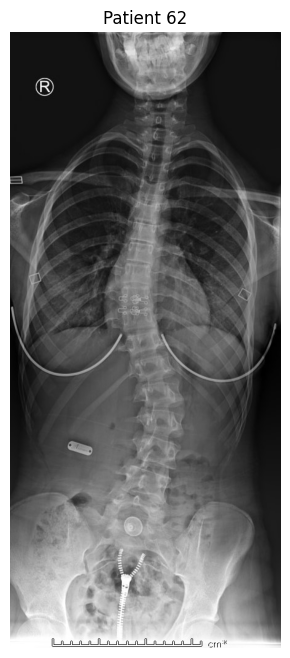

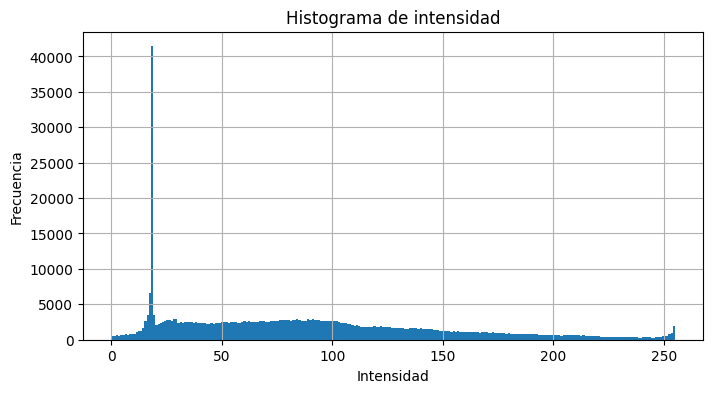

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_136.jpg
Shape: (4286, 1973, 3)
Dtype: uint8
Min: 0 Max: 211
Mean: 123.7360610661097 Std: 56.390727358894665
P1: 2.0 P50: 138.0 P99: 197.0


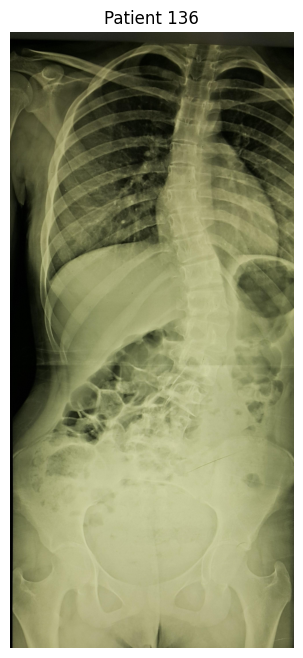

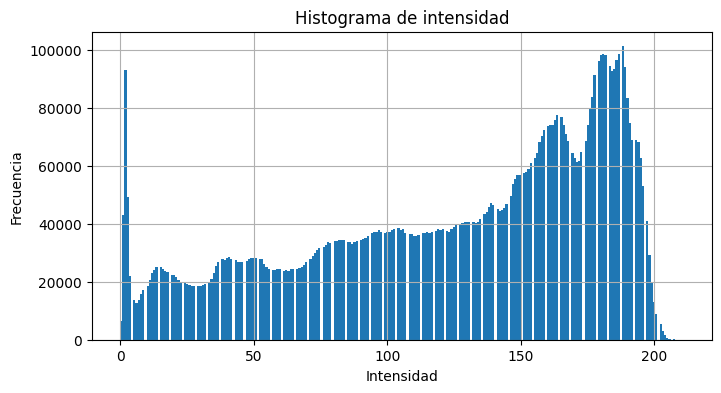

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_152.jpg
Shape: (989, 368, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 104.79984173737196 Std: 69.40712585793257
P1: 1.0 P50: 109.0 P99: 250.0


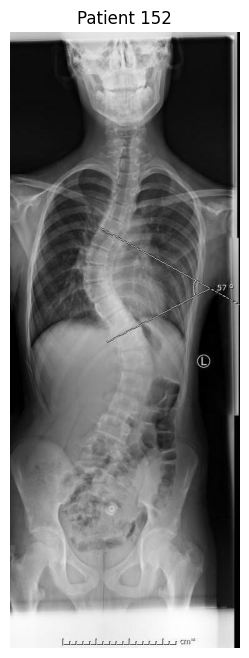

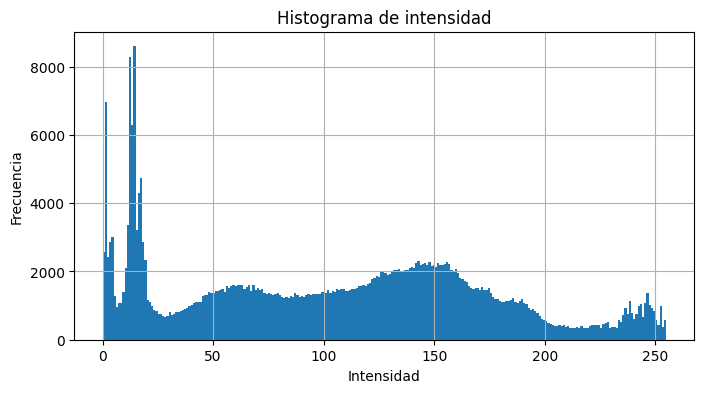

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_139.jpg
Shape: (2485, 1373, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 100.11869732598065 Std: 78.34547202441236
P1: 0.0 P50: 91.0 P99: 245.0


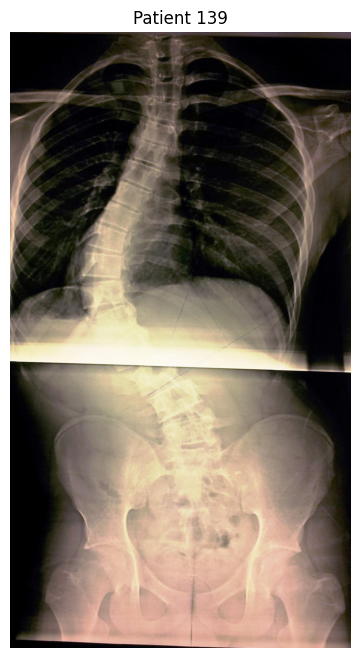

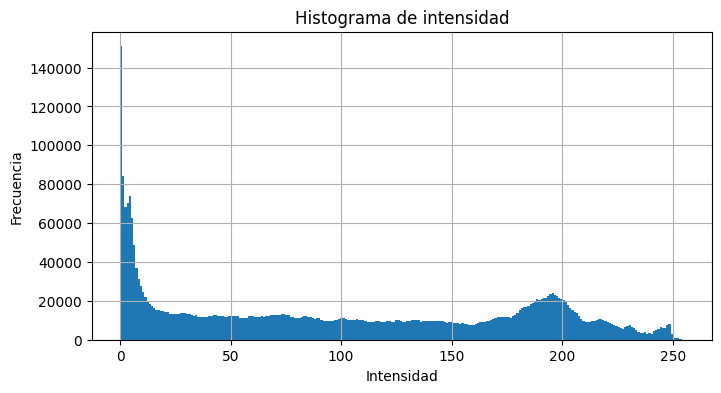

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Normal/N_10.jpg
Shape: (778, 311, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 108.04102364873242 Std: 60.62200709028812
P1: 8.0 P50: 110.0 P99: 222.0


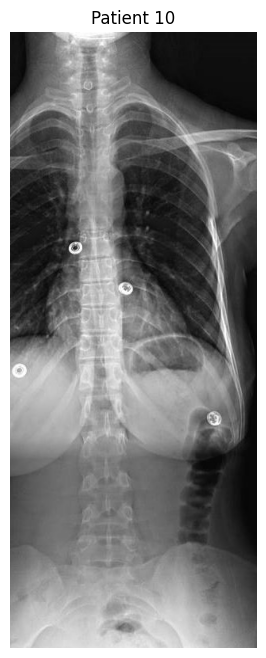

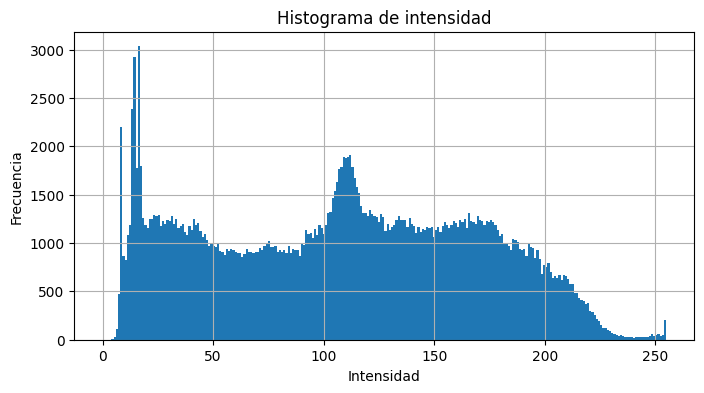

Path: /content/spine-curve-geometric-representation/MaIA_Scoliosis_Dataset/Scoliosis/S_54.jpg
Shape: (818, 413, 3)
Dtype: uint8
Min: 0 Max: 255
Mean: 90.05578775374889 Std: 56.638766211774474
P1: 0.0 P50: 96.0 P99: 202.0


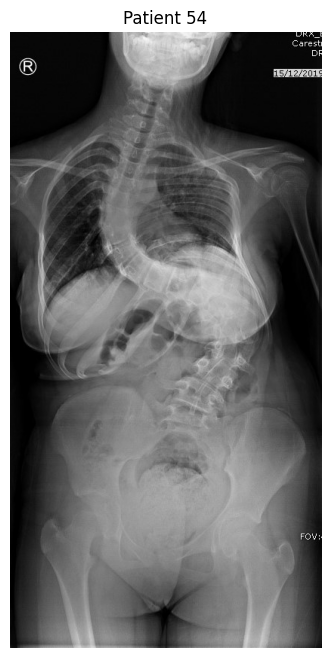

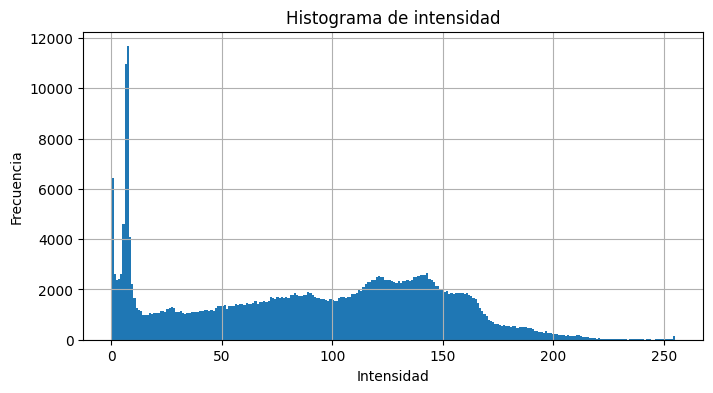

In [9]:
def show_image_with_hist(path, title=None):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    if img is None:
        print("No se pudo cargar:", path)
        return

    if img.ndim == 3:
        img_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_show = img
        gray = img

    print("Path:", path)
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min:", gray.min(), "Max:", gray.max())
    print("Mean:", gray.mean(), "Std:", gray.std())
    print("P1:", np.percentile(gray, 1), "P50:", np.percentile(gray, 50), "P99:", np.percentile(gray, 99))

    plt.figure(figsize=(6, 8))
    plt.imshow(img_show, cmap="gray")
    plt.axis("off")
    plt.title(title or Path(path).name)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(gray.ravel(), bins=256)
    plt.xlabel("Intensidad")
    plt.ylabel("Frecuencia")
    plt.title("Histograma de intensidad")
    plt.grid(True)
    plt.show()

# Ver 5 imágenes aleatorias
sample_df = audit_df[audit_df["exists"]].sample(10, random_state=42)

for _, row in sample_df.iterrows():
    show_image_with_hist(row["rx_path"], title=f"Patient {row['patient_id']}")

In [10]:
print("Imágenes con menor intensidad media:")
display(audit_df.sort_values("mean").head(10))

print("Imágenes con mayor intensidad media:")
display(audit_df.sort_values("mean", ascending=False).head(10))

print("Imágenes con menor contraste:")
display(audit_df.sort_values("std").head(10))

print("Imágenes con mayor contraste:")
display(audit_df.sort_values("std", ascending=False).head(10))

main_resolution = resolution_summary.iloc[0]
main_h = main_resolution["height"]
main_w = main_resolution["width"]

weird_resolution_df = audit_df[
    (audit_df["height"] != main_h) |
    (audit_df["width"] != main_w)
]

print("Resolución dominante:", main_h, main_w)
print("Imágenes con resolución diferente:", len(weird_resolution_df))

display(weird_resolution_df.head(20))

Imágenes con menor intensidad media:


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
146,True,2662,1067,3,uint8,0.0,137.0,42.645659,32.400514,1.0,42.0,107.0,97,/content/spine-curve-geometric-representation/...
209,True,1010,551,3,uint8,0.0,255.0,52.320584,54.310437,0.0,36.0,188.0,165,/content/spine-curve-geometric-representation/...
159,True,2074,726,3,uint8,1.0,253.0,67.572605,55.094171,4.0,49.0,199.0,111,/content/spine-curve-geometric-representation/...
114,True,1003,475,3,uint8,0.0,255.0,67.688054,54.353316,0.0,65.0,190.0,64,/content/spine-curve-geometric-representation/...
92,True,1018,419,3,uint8,0.0,255.0,67.987567,49.321305,4.0,62.0,180.0,42,/content/spine-curve-geometric-representation/...
116,True,797,361,3,uint8,0.0,255.0,69.477702,49.646436,0.0,72.0,174.0,66,/content/spine-curve-geometric-representation/...
243,True,995,458,3,uint8,0.0,255.0,70.484067,50.128537,0.0,60.0,191.0,200,/content/spine-curve-geometric-representation/...
60,True,717,291,3,uint8,0.0,226.0,71.138425,40.141066,11.0,64.0,177.0,61,/content/spine-curve-geometric-representation/...
90,True,997,552,3,uint8,0.0,255.0,71.314896,50.200614,4.0,69.0,189.0,40,/content/spine-curve-geometric-representation/...
87,True,754,298,3,uint8,0.0,197.0,71.638278,37.683876,20.0,67.0,160.0,37,/content/spine-curve-geometric-representation/...


Imágenes con mayor intensidad media:


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
38,True,889,222,3,uint8,0.0,255.0,183.297703,36.040456,78.0,187.0,236.0,39,/content/spine-curve-geometric-representation/...
150,True,3125,975,3,uint8,0.0,255.0,163.261770,44.944547,16.0,169.0,254.0,102,/content/spine-curve-geometric-representation/...
218,True,891,403,3,uint8,0.0,255.0,154.601866,50.811776,20.0,175.0,232.0,174,/content/spine-curve-geometric-representation/...
180,True,3799,1379,3,uint8,0.0,255.0,153.295391,65.400477,21.0,172.0,245.0,135,/content/spine-curve-geometric-representation/...
151,True,2475,822,3,uint8,0.0,255.0,153.090412,62.843089,27.0,153.0,255.0,103,/content/spine-curve-geometric-representation/...
178,True,3002,1039,3,uint8,1.0,237.0,152.008347,37.787112,35.0,161.0,206.0,133,/content/spine-curve-geometric-representation/...
226,True,1019,496,3,uint8,0.0,255.0,146.462137,63.078731,51.0,149.0,255.0,183,/content/spine-curve-geometric-representation/...
33,True,927,202,3,uint8,0.0,255.0,146.423772,30.304003,52.0,151.0,195.0,34,/content/spine-curve-geometric-representation/...
236,True,819,296,3,uint8,24.0,252.0,143.546505,58.488702,40.0,148.0,229.0,193,/content/spine-curve-geometric-representation/...
164,True,1884,705,3,uint8,1.0,255.0,142.535752,65.342958,35.0,158.0,252.0,119,/content/spine-curve-geometric-representation/...


Imágenes con menor contraste:


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
48,True,753,123,3,uint8,28.0,208.0,102.511483,29.691198,43.0,111.0,157.0,49,/content/spine-curve-geometric-representation/...
33,True,927,202,3,uint8,0.0,255.0,146.423772,30.304003,52.0,151.0,195.0,34,/content/spine-curve-geometric-representation/...
102,True,840,239,3,uint8,9.0,196.0,111.916975,31.710777,20.0,121.0,166.0,52,/content/spine-curve-geometric-representation/...
58,True,827,167,3,uint8,1.0,185.0,93.238493,31.994960,16.0,96.0,163.0,59,/content/spine-curve-geometric-representation/...
146,True,2662,1067,3,uint8,0.0,137.0,42.645659,32.400514,1.0,42.0,107.0,97,/content/spine-curve-geometric-representation/...
127,True,727,232,3,uint8,16.0,213.0,99.413437,33.757836,26.0,102.0,174.0,77,/content/spine-curve-geometric-representation/...
91,True,787,270,3,uint8,6.0,255.0,103.223554,33.968728,18.0,108.0,161.0,41,/content/spine-curve-geometric-representation/...
247,True,885,213,3,uint8,0.0,255.0,102.278316,34.215085,11.0,114.0,154.0,204,/content/spine-curve-geometric-representation/...
34,True,712,230,3,uint8,4.0,176.0,71.957224,34.337241,9.0,73.0,147.0,35,/content/spine-curve-geometric-representation/...
2,True,939,206,3,uint8,0.0,255.0,94.283735,34.371625,27.0,99.0,156.0,3,/content/spine-curve-geometric-representation/...


Imágenes con mayor contraste:


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
149,True,2589,983,3,uint8,1.0,255.0,136.425884,88.525000,6.0,161.0,248.0,101,/content/spine-curve-geometric-representation/...
182,True,3213,1289,3,uint8,0.0,249.0,113.240859,88.238993,1.0,112.0,243.0,137,/content/spine-curve-geometric-representation/...
160,True,2718,1055,3,uint8,0.0,255.0,104.536478,83.696870,6.0,86.0,252.0,113,/content/spine-curve-geometric-representation/...
177,True,2491,736,3,uint8,0.0,255.0,140.789522,82.358700,28.0,142.0,253.0,132,/content/spine-curve-geometric-representation/...
94,True,2496,932,3,uint8,0.0,255.0,112.994454,81.001061,11.0,91.0,255.0,44,/content/spine-curve-geometric-representation/...
202,True,3392,1803,3,uint8,0.0,255.0,123.601569,79.844519,8.0,126.0,248.0,157,/content/spine-curve-geometric-representation/...
161,True,2779,1160,3,uint8,3.0,255.0,120.309161,78.881590,11.0,115.0,252.0,114,/content/spine-curve-geometric-representation/...
184,True,2485,1373,3,uint8,0.0,255.0,100.118697,78.345472,0.0,91.0,245.0,139,/content/spine-curve-geometric-representation/...
144,True,3072,1517,3,uint8,0.0,255.0,99.740658,77.688725,5.0,83.0,255.0,95,/content/spine-curve-geometric-representation/...
191,True,3962,1855,3,uint8,0.0,255.0,124.393108,77.560238,12.0,130.0,229.0,146,/content/spine-curve-geometric-representation/...


Resolución dominante: 595 150
Imágenes con resolución diferente: 249


,exists,height,width,channels,dtype,min,max,mean,std,p1,p50,p99,patient_id,rx_path
0,True,971,259,3,uint8,0.0,255.0,102.811837,45.020259,9.0,111.0,182.0,1,/content/spine-curve-geometric-representation/...
1,True,828,218,3,uint8,0.0,255.0,107.687680,59.316895,18.0,101.0,245.0,2,/content/spine-curve-geometric-representation/...
2,True,939,206,3,uint8,0.0,255.0,94.283735,34.371625,27.0,99.0,156.0,3,/content/spine-curve-geometric-representation/...
3,True,878,204,3,uint8,0.0,255.0,98.324875,45.059816,19.0,99.0,212.0,4,/content/spine-curve-geometric-representation/...
4,True,666,172,3,uint8,0.0,221.0,99.736609,49.714559,0.0,106.0,189.0,5,/content/spine-curve-geometric-representation/...
5,True,920,186,3,uint8,0.0,255.0,102.552250,42.846691,19.0,106.0,184.0,6,/content/spine-curve-geometric-representation/...
6,True,937,220,3,uint8,0.0,255.0,92.644931,35.037818,27.0,98.0,156.0,7,/content/spine-curve-geometric-representation/...
7,True,858,229,3,uint8,0.0,255.0,94.061558,41.518637,24.0,100.0,179.0,8,/content/spine-curve-geometric-representation/...
8,True,633,157,3,uint8,0.0,213.0,94.135941,49.243841,0.0,98.0,176.0,9,/content/spine-curve-geometric-representation/...
9,True,778,311,3,uint8,0.0,255.0,108.041024,60.622007,8.0,110.0,222.0,10,/content/spine-curve-geometric-representation/...
